<a href="https://colab.research.google.com/github/SakshamSharma2006/Advance-Data-science/blob/main/DCGAN_FashionMNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DCGAN — Deep Convolutional Generative Adversarial Network
## Dataset: Fashion-MNIST

A **DCGAN** uses convolutional layers instead of fully-connected layers inside a GAN.

- The **Generator** takes a random noise vector and upsamples it into a 28×28 image using `ConvTranspose2d` layers.
- The **Discriminator** takes a 28×28 image and downsamples it using `Conv2d` layers to output a single probability — **real (1) or fake (0)**.

Both are trained together in a minimax game:
- D tries to correctly classify real vs fake.
- G tries to fool D into thinking its fake images are real.

### Why Fashion-MNIST?
Fashion-MNIST contains 60,000 grayscale 28×28 images across 10 clothing categories (T-shirts, trousers, sneakers, bags, etc.). It is a drop-in replacement for MNIST but produces far more visually interesting generated results.

In [1]:
import torch
from torch import nn                              # Neural network modules
from torch.utils.data import DataLoader           # Utility to batch and shuffle data
from torchvision import datasets, transforms      # Fashion-MNIST dataset and image processing
from torchvision.utils import make_grid           # Helper to visualize images in a grid
import matplotlib.pyplot as plt

# ── Hyperparameters ─────────────────────────────────────────────────────────
device     = "cuda" if torch.cuda.is_available() else "cpu"  # Use GPU if available
lr         = 0.0002   # Learning rate for Adam optimizer
beta1      = 0.5      # Beta1 for Adam — controls first moment decay rate
batch_size = 128      # Number of training samples per pass
latent_dim = 100      # Size of the random noise vector (input to Generator)
epochs     = 50       # Number of times to loop over the entire dataset

# ── Data Preparation ────────────────────────────────────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))          # Normalize pixel values to [-1, 1]
])

# Download and load Fashion-MNIST (clothing images, same 28x28 format as MNIST)
dataset    = datasets.FashionMNIST(root="data/", train=True, download=True, transform=transform)

# Create a DataLoader to feed data in shuffled mini-batches
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

print(f"Dataset size : {len(dataset)} images")
print(f"Batches/epoch: {len(dataloader)}")
print(f"Running on   : {device}")

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.77MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.5MB/s]

Dataset size : 60000 images
Batches/epoch: 469
Running on   : cuda


## Generator

The Generator starts from a **latent noise vector** of shape `(latent_dim, 1, 1)` and progressively **upsamples** it into a 28×28 image using transposed convolutions.

```
Noise (100×1×1)  →  256×7×7  →  128×14×14  →  1×28×28
```

- `ConvTranspose2d` — learnable upsampling (inverse of Conv2d)
- `BatchNorm2d`     — stabilises training by normalising activations
- `ReLU`            — activation inside G
- `Tanh`            — squashes output to [-1, 1] to match normalised data

In [2]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()           # Initialise parent class
        self.main = nn.Sequential(
            # Input: latent_dim x 1 x 1 — ConvTranspose2d "blows up" the noise
            nn.ConvTranspose2d(latent_dim, 256, 7, 1, 0, bias=False),  # Output: 256 x 7 x 7
            nn.BatchNorm2d(256),                    # Normalise to stabilise training
            nn.ReLU(True),                          # Activation function for Generator

            # State: 256 x 7 x 7  →  Upsample to 14x14
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),         # Output: 128 x 14 x 14
            nn.BatchNorm2d(128),
            nn.ReLU(True),

            # State: 128 x 14 x 14  →  Upsample to 28x28 (final image size)
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),           # Output: 1 x 28 x 28
            nn.Tanh()                               # Maps output to [-1, 1] to match normalised data
        )

    def forward(self, x):
        return self.main(x)                         # Pass noise through the sequence

# Quick sanity check — confirm the output shape is correct
test_noise = torch.randn(1, latent_dim, 1, 1)
gen_test   = Generator()
print("Generator output shape:", gen_test(test_noise).shape)  # Expected: torch.Size([1, 1, 28, 28])

Generator output shape: torch.Size([1, 1, 28, 28])


## Discriminator

The Discriminator receives a 28×28 image (real or generated) and **downsamples** it through convolutional layers, ending with a single probability score.

```
Image (1×28×28)  →  64×14×14  →  128×7×7  →  1×1×1  →  scalar
```

- `Conv2d`       — learnable downsampling
- `LeakyReLU`    — allows small gradients for negative values (better for D than ReLU)
- `BatchNorm2d`  — normalises activations
- `Sigmoid`      — outputs a probability in [0, 1]

In [3]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # Input: 1 x 28 x 28 (the image)
            nn.Conv2d(1, 64, 4, 2, 1, bias=False),                     # Output: 64 x 14 x 14
            nn.LeakyReLU(0.2, inplace=True),        # LeakyReLU — keeps small negative gradients

            # State: 64 x 14 x 14  →  Downsample further
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),                   # Output: 128 x 7 x 7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # State: 128 x 7 x 7  →  Flatten to a single probability value
            nn.Conv2d(128, 1, 7, 1, 0, bias=False),                    # Output: 1 x 1 x 1
            nn.Sigmoid()                            # Maps output to [0, 1]  (0=Fake, 1=Real)
        )

    def forward(self, x):
        return self.main(x).view(-1, 1)             # Reshape to (BatchSize, 1)

# Quick sanity check
test_img  = torch.randn(1, 1, 28, 28)
disc_test = Discriminator()
print("Discriminator output shape:", disc_test(test_img).shape)  # Expected: torch.Size([1, 1])

Discriminator output shape: torch.Size([1, 1])


## Initialise Models, Loss, and Optimisers

- **BCELoss** — Binary Cross-Entropy, the standard loss for binary classification (real vs fake)
- **Adam** — adaptive gradient optimiser; `beta1=0.5` is the DCGAN paper recommendation for stability

In [4]:
# Instantiate models and move them to GPU/CPU
netG = Generator().to(device)
netD = Discriminator().to(device)

# Loss function — Binary Cross Entropy for real/fake classification
criterion  = nn.BCELoss()

# Separate optimisers for G and D
optimizerD = torch.optim.Adam(netD.parameters(), lr=lr, betas=(beta1, 0.999))  # D Optimiser
optimizerG = torch.optim.Adam(netG.parameters(), lr=lr, betas=(beta1, 0.999))  # G Optimiser

print("Models ready!")
print(f"  Generator     params: {sum(p.numel() for p in netG.parameters()):,}")
print(f"  Discriminator params: {sum(p.numel() for p in netD.parameters()):,}")

Models ready!
  Generator     params: 1,781,504
  Discriminator params: 138,624


## Training Loop

Each iteration involves two steps:

**Step 1 — Train the Discriminator (D)**
1. Feed real images → D should output 1 (real)
2. Feed fake images from G → D should output 0 (fake)
3. Combine both losses, backpropagate, update D's weights

**Step 2 — Train the Generator (G)**
1. Feed fake images to D again (without detaching)
2. G's goal: make D output 1 for its fakes → use label=1 as target
3. Backpropagate through D into G, update G's weights only

In [5]:
for epoch in range(epochs):
    for i, (real_imgs, _) in enumerate(dataloader):    # Iterate through batches
        curr_batch_size = real_imgs.size(0)             # Actual batch size (last batch may be smaller)
        real_imgs = real_imgs.to(device)                # Move images to GPU/CPU

        # ── Train Discriminator ─────────────────────────────────────────────
        netD.zero_grad()                                # Reset gradients for D
        label_real = torch.ones(curr_batch_size, 1).to(device)   # Target for real images = 1
        label_fake = torch.zeros(curr_batch_size, 1).to(device)  # Target for fake images = 0

        output_real  = netD(real_imgs)                  # D scores real images
        lossD_real   = criterion(output_real, label_real)         # Loss on real images

        noise        = torch.randn(curr_batch_size, latent_dim, 1, 1).to(device)  # Random noise
        fake_imgs    = netG(noise)                      # G generates fake images from noise
        output_fake  = netD(fake_imgs.detach())         # D scores fake images (.detach() stops gradients reaching G)
        lossD_fake   = criterion(output_fake, label_fake)         # Loss on fake images

        lossD = lossD_real + lossD_fake                 # Total D loss
        lossD.backward()                                # Compute gradients for D
        optimizerD.step()                               # Update D weights

        # ── Train Generator ──────────────────────────────────────────────────
        netG.zero_grad()                                # Reset gradients for G
        output  = netD(fake_imgs)                       # D re-scores fake images (no detach — gradients flow to G)
        lossG   = criterion(output, label_real)         # G wants D to think its fakes are real (target = 1)
        lossG.backward()                                # Compute gradients for G
        optimizerG.step()                               # Update G weights

    # Print progress every epoch
    print(f"Epoch [{epoch+1:02d}/{epochs}]  Loss D: {lossD.item():.4f}  |  Loss G: {lossG.item():.4f}")

Epoch [01/50]  Loss D: 0.0007  |  Loss G: 7.6882
Epoch [02/50]  Loss D: 0.9961  |  Loss G: 1.7535
Epoch [03/50]  Loss D: 0.9784  |  Loss G: 1.2144
Epoch [04/50]  Loss D: 1.0073  |  Loss G: 1.2173
Epoch [05/50]  Loss D: 1.1102  |  Loss G: 1.1797
Epoch [06/50]  Loss D: 1.0121  |  Loss G: 0.9743
Epoch [07/50]  Loss D: 0.9416  |  Loss G: 1.0297
Epoch [08/50]  Loss D: 1.0146  |  Loss G: 1.4936
Epoch [09/50]  Loss D: 1.1487  |  Loss G: 1.0285
Epoch [10/50]  Loss D: 1.1600  |  Loss G: 1.6506
Epoch [11/50]  Loss D: 1.0152  |  Loss G: 1.1751
Epoch [12/50]  Loss D: 1.0633  |  Loss G: 1.3733
Epoch [13/50]  Loss D: 1.1947  |  Loss G: 1.5762
Epoch [14/50]  Loss D: 1.0976  |  Loss G: 0.8903
Epoch [15/50]  Loss D: 1.0744  |  Loss G: 1.1295
Epoch [16/50]  Loss D: 1.0572  |  Loss G: 0.9754
Epoch [17/50]  Loss D: 1.0985  |  Loss G: 1.3932
Epoch [18/50]  Loss D: 1.0369  |  Loss G: 1.8044
Epoch [19/50]  Loss D: 1.1045  |  Loss G: 0.8111
Epoch [20/50]  Loss D: 1.0257  |  Loss G: 1.0630
Epoch [21/50]  Loss 

## Visualise Generated Fashion Images

After training, we pass 64 random noise vectors through the Generator and display the resulting images in an 8×8 grid.

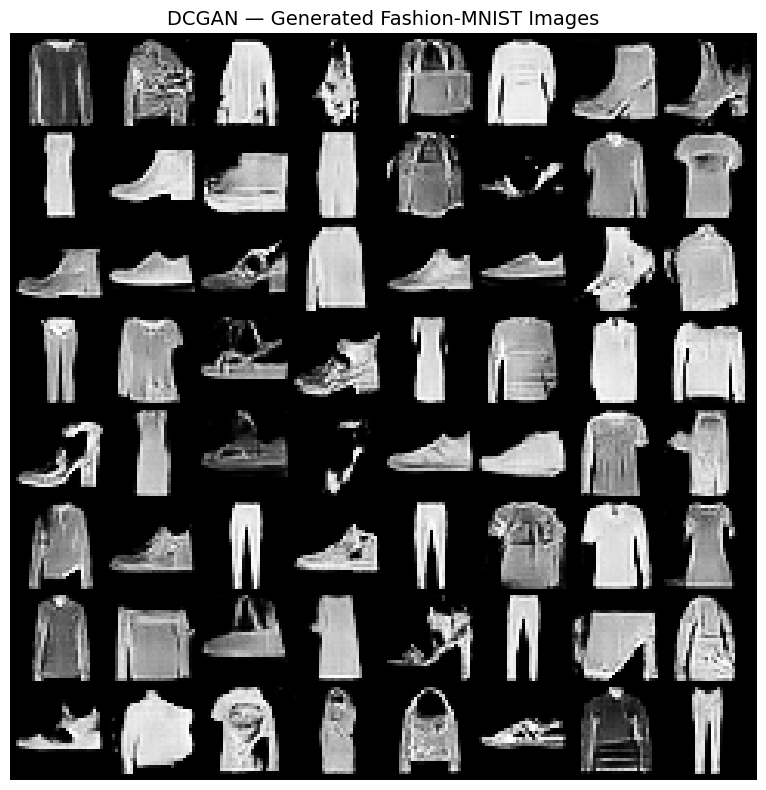

In [7]:
# Class names for Fashion-MNIST (for reference)
class_names = ['T-shirt/top','Trouser','Pullover','Dress','Coat',
               'Sandal','Shirt','Sneaker','Bag','Ankle boot']

with torch.no_grad():                               # Turn off gradient calculation for inference
    test_noise = torch.randn(64, latent_dim, 1, 1).to(device)  # 64 random noise vectors
    generated  = netG(test_noise).cpu()             # Generate 64 images
    grid       = make_grid(generated, nrow=8, normalize=True)   # Arrange into 8x8 grid

plt.figure(figsize=(8, 8))
plt.title("DCGAN — Generated Fashion-MNIST Images", fontsize=14)
plt.imshow(grid.permute(1, 2, 0), cmap='gray')     # (C,H,W) → (H,W,C) for matplotlib
plt.axis('off')
plt.tight_layout()
plt.show()